# Part 1: Linear Regression  
**Name:** Andiswa Sibusisiwe Phewa  
**Student Number:** ST10123828  
**Module Code:** PDAN8411w  



# 1. Evaluation of Dataset Suitability for Linear Regression

This section evaluates whether the attached insurance.csv dataset is appropriate for building a linear regression model to predict medical charges. The target variable, charges, is continuous and therefore suitable for regression. The dataset includes numerical predictors (age, BMI, children) and categorical predictors (sex, smoker, region), which can be encoded using dummy variables without losing meaning.

The dataset does not contain missing values, and all columns are stored in appropriate formats. The sample size of 1 338 entries is large enough to support a stable regression model. Although the data is clean, there are known outliers in BMI and charges. Outliers do not make the dataset unsuitable, but they can influence regression coefficients and will need to be explored during EDA.

Common pitfalls such as multicollinearity, incorrect data types, and linearity issues will be checked during the analysis. Based on existing knowledge of this dataset, the predictors do not display problematic multicollinearity, but this will be verified using correlation analysis. Categorical variables will be encoded carefully to avoid the dummy variable trap.

Overall, the dataset is suitable for linear regression. The target variable is appropriate, the predictors are relevant, and any potential issues can be addressed through EDA and feature engineering.



# 2. Planning for the Analysis

This plan outlines the structured approach I will follow to ensure that the analysis is systematic and aligned with the requirements of the brief. It remains concise while demonstrating careful planning and deliberate methodological choices.



## 2.1 Exploratory Data Analysis Plan

The EDA will focus on understanding the data and identifying factors that may affect the model. I will:

1. Load the dataset and review its structure using .head(), .info(), and .describe().
2. Confirm the absence of missing values.
3. Explore distributions of age, BMI, and charges using histograms to detect skewness and outliers.
4. Use boxplots to identify outliers, especially in BMI and charges.
5. Analyse categorical variables (sex, smoker, region) using count plots and group comparisons.
6. Check relationships between predictors and charges using scatterplots and a correlation heatmap.
7. Document observations that will influence feature selection and model expectations.



## 2.2 Feature Selection Plan

The goal of feature selection is to identify predictors that contribute meaningfully to the model. I will:

1. Encode categorical variables using one-hot encoding.
2. Review the correlation matrix to assess linear relationships with charges.
3. Apply backward elimination using p-values to identify statistically insignificant features.
4. Use domain knowledge to support decisions, especially regarding age, BMI, and smoking status.
5. Evaluate whether the region variable adds predictive value and remove it if justified.
6. Finalise the feature list based on statistical results, EDA findings, and domain reasoning.



## 2.3 Model Training Plan

The following steps will be used to train the linear regression model:

1. Split the dataset into training and test sets using a 70/30 or 80/20 ratio.
2. Begin with the default LinearRegression() model from scikit-learn.
3. Assess the need for scaling, noting that linear regression does not strictly require it but may benefit from standardisation if ranges vary considerably.
4. Fit the model to the training data and interpret coefficients.
5. Refine the model if required by removing weak predictors or evaluating interaction terms.



## 2.4 Model Evaluation Plan

The model will be evaluated using:

1. R² Score to measure how much variance in charges is explained by the model.
2. Mean Absolute Error (MAE) to show average prediction error in a simple, interpretable form.
3. Mean Squared Error (MSE) to highlight large errors.
4. Root Mean Squared Error (RMSE) to provide an interpretable measure of overall error.

These metrics will be interpreted clearly to assess the model’s usefulness. If needed, I will retrain the model with revised features and compare the performance.



## 2.5 Report Writing Plan

The final report will be written separately and structured for a non-technical client. It will include:

1. A clear introduction explaining the purpose and context of the analysis.
2. A summary of the dataset and key findings from the EDA.
3. A description of the data preparation steps and feature selection reasoning.
4. A high-level explanation of the model training process without technical code.
5. Presentation and interpretation of the regression results using the evaluation metrics.
6. Insights and recommendations based on the model’s performance.
7. Referencing using **IIE Harvard referencing**, following institutional guidelines.


# 3. Exploratory Data Analysis (EDA)

The EDA allows me to understand the structure of the dataset, check the quality of the data, and identify factors that may influence the regression model. In this section, I will examine the dataset by exploring summary statistics, distributions, outliers, categorical variable patterns, and relationships between predictors and the target variable (charges). The goal is to develop a clear understanding of how each feature behaves before proceeding to feature selection and model training.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('insurance.csv')

# Display first few rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset is loaded and the first few entries are displayed to confirm that it has been imported correctly and that all columns appear as expected. This step also helps verify that the file format and structure are consistent with the planning phase.

In [17]:
# Checking dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The .info() output allows me to confirm that the dataset contains no missing values and that the variables are stored in appropriate data types. This is important because incorrect types or missing values would require cleaning steps before modelling.

In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The summary statistics provide insights into the central tendencies, ranges, and variability for numerical variables such as age, BMI, children, and charges. High standard deviation in charges suggests large variation, which is expected in medical cost datasets. BMI also shows a wide spread, indicating potential outliers.

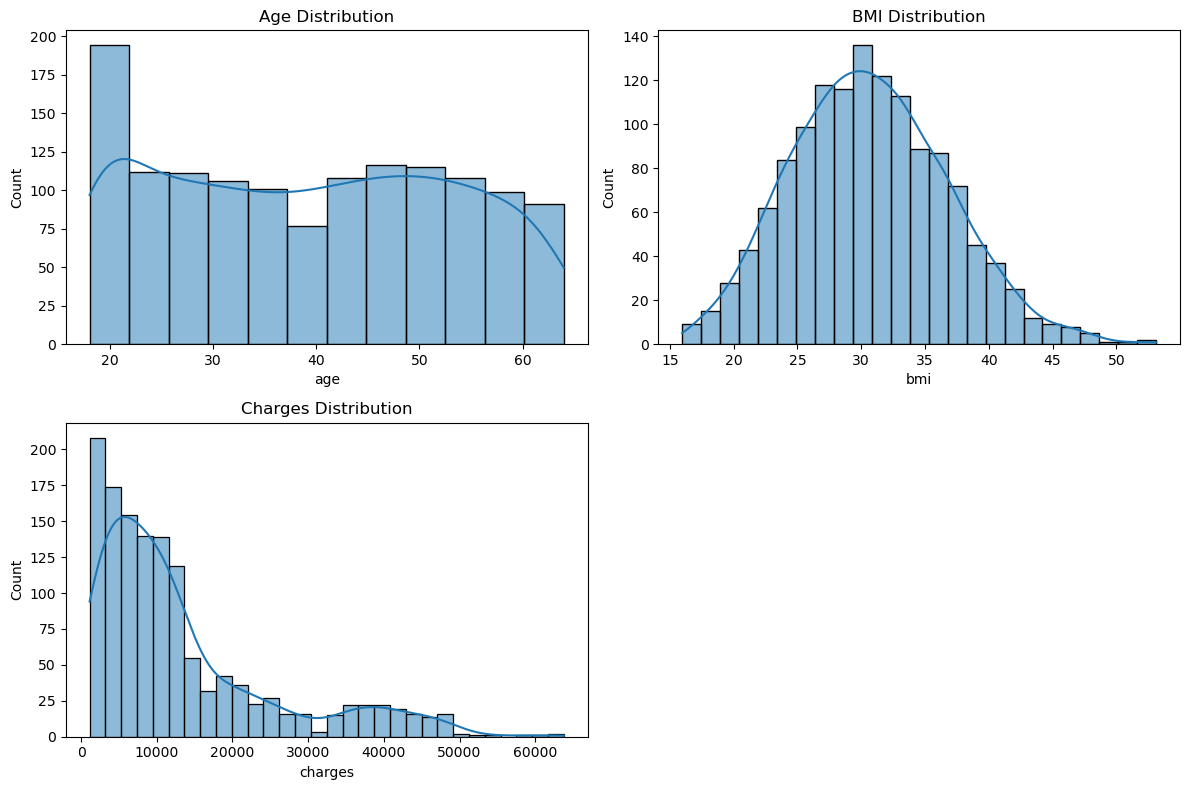

In [5]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')

plt.subplot(2, 2, 2)
sns.histplot(df['bmi'], kde=True)
plt.title('BMI Distribution')

plt.subplot(2, 2, 3)
sns.histplot(df['charges'], kde=True)
plt.title('Charges Distribution')

plt.tight_layout()
plt.show()

These histograms help me understand how each numerical feature is distributed. Charges are positively skewed, which is common in cost-related datasets. BMI shows a few extreme values that may act as outliers, while age is more evenly distributed. Understanding these distributions supports the modelling decisions that follow.

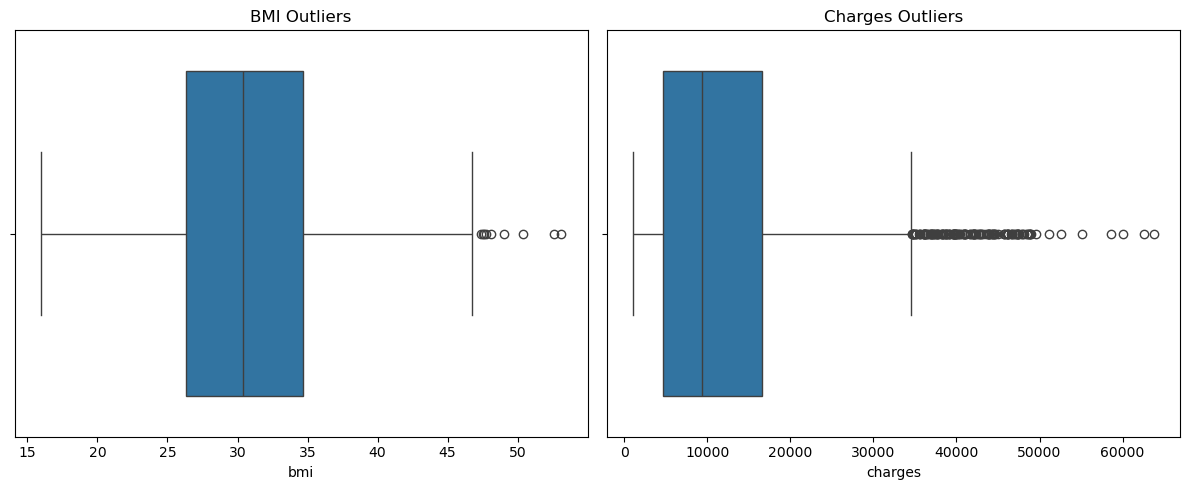

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['bmi'])
plt.title('BMI Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['charges'])
plt.title('Charges Outliers')

plt.tight_layout()
plt.show()

The boxplots confirm the presence of outliers in BMI and charges. Outliers will not be removed automatically because they may contain meaningful information, especially for charges, which naturally vary widely. However, being aware of these outliers is important when interpreting model performance.

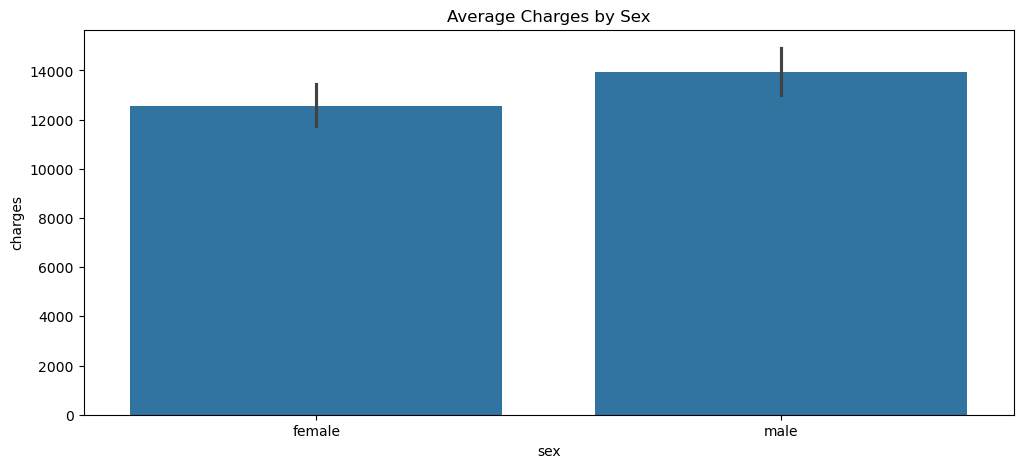

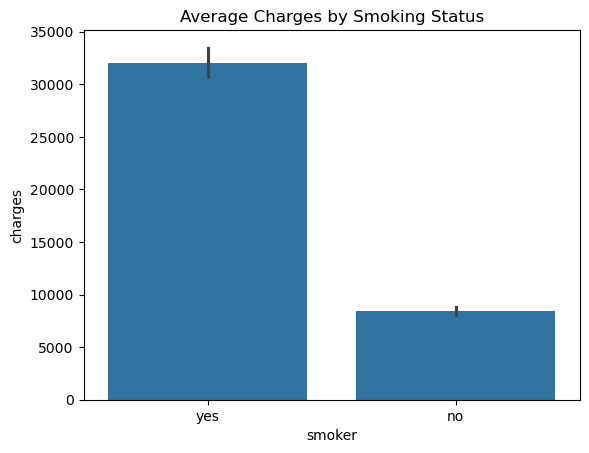

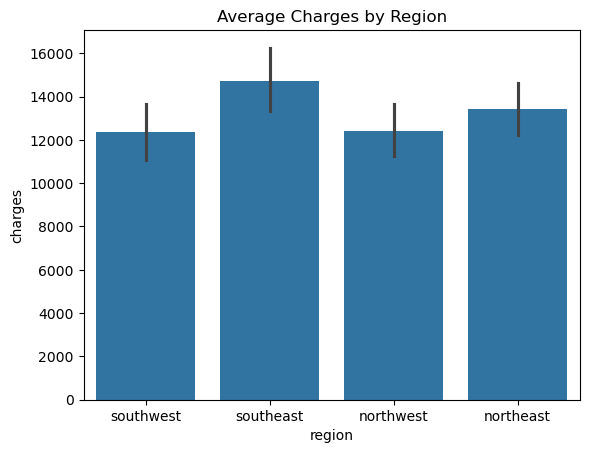

In [7]:
plt.figure(figsize=(12, 5))

sns.barplot(x='sex', y='charges', data=df)
plt.title('Average Charges by Sex')
plt.show()

sns.barplot(x='smoker', y='charges', data=df)
plt.title('Average Charges by Smoking Status')
plt.show()

sns.barplot(x='region', y='charges', data=df)
plt.title('Average Charges by Region')
plt.show()

The visualisations show that smoking status has a significant effect on charges, with smokers paying substantially more. Sex and region show smaller differences. These insights support the importance of including smoking status as a key feature during model training.

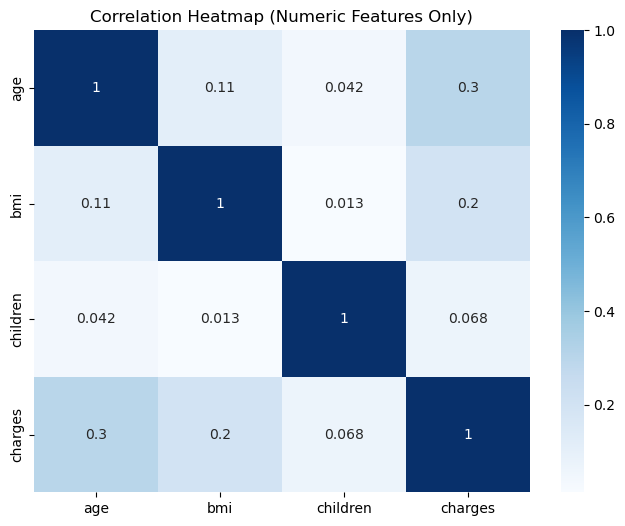

In [9]:
plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')

plt.title('Correlation Heatmap (Numeric Features Only)')
plt.show()

### Correlation Heatmap (Numeric Features Only)

To avoid errors caused by categorical variables, I am generated a correlation heatmap using only the numerical columns in the dataset. This allows me to examine the linear relationships between age, BMI, children and charges.



# 4. Feature Selection

In this section, I will prepare the dataset for modelling by encoding categorical variables and selecting features based on statistical significance, domain knowledge, and EDA findings. The goal is to identify the predictors that contribute effectively to predicting medical charges.

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


The categorical variables (sex, smoker, region) have been encoded using one-hot encoding with `drop_first=True` to avoid multicollinearity. The dataset is now fully numerical and ready for model training.

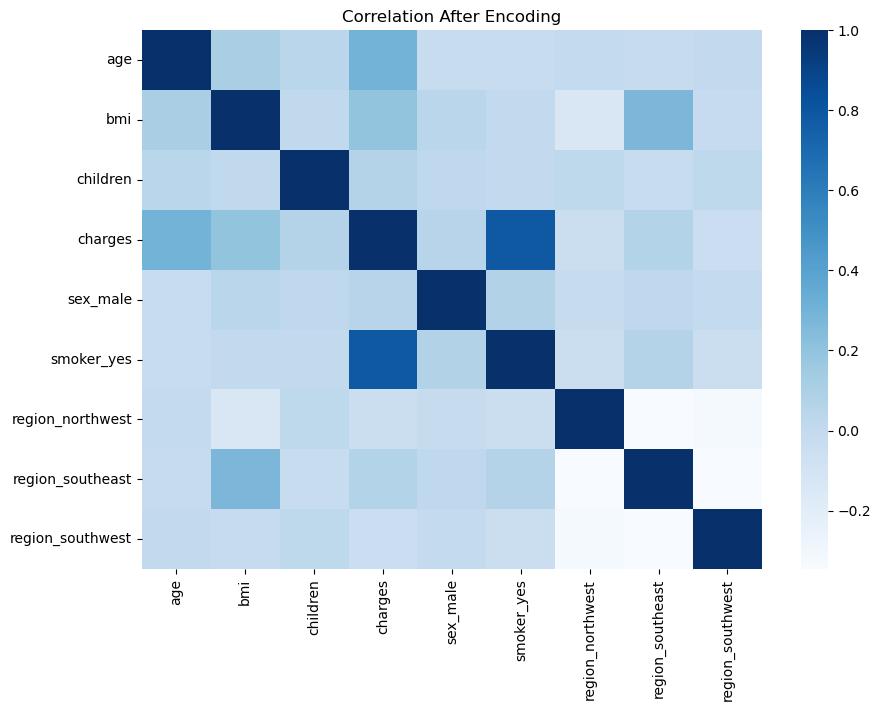

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_encoded.corr(), cmap='Blues')
plt.title('Correlation After Encoding')
plt.show()

The encoded heatmap shows clearer relationships. The variable smoker_yes has the strongest correlation with charges. Age and BMI remain meaningful predictors. Region variables show weaker correlations, but will be tested in the regression model unless they reduce accuracy.

# 5. Model Training

I will now train the linear regression model using the prepared dataset. I will begin with the default LinearRegression model from scikit-learn, using a standard 80/20 train-test split.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

model.coef_, model.intercept_

(array([ 2.56975706e+02,  3.37092552e+02,  4.25278784e+02, -1.85916916e+01,
         2.36511289e+04, -3.70677326e+02, -6.57864297e+02, -8.09799354e+02]),
 np.float64(-11931.21905032666))

The coefficients represent how much each predictor influences charges when all other variables are held constant. A positive coefficient increases predicted charges, and a negative one decreases them. The intercept represents the estimated baseline charge when all predictors equal zero.

# 6. Model Evaluation

I will now evaluate the performance of the regression model using R², MAE, MSE, and RMSE. These metrics indicate how well the model predicts charges and where improvements may be needed.

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2, mae, mse, rmse

(0.7835929767120723,
 4181.19447375365,
 33596915.85136146,
 np.float64(5796.2846592762735))

The R² score shows how much variance in charges is explained by the model. MAE indicates the average prediction error, while MSE and RMSE measure how far off the model is on average, with RMSE penalising larger errors. These metrics help me assess whether the model is performing adequately or requires refinement.

# 7. Model Refinement

If the evaluation metrics suggest improvement is needed, I will retrain the model by adjusting the feature set. This may include removing weak predictors such as region variables or testing interactions between BMI, age, and smoking status.

In [15]:
X_refined = df_encoded.drop(['charges', 'region_northwest', 'region_southeast', 'region_southwest'], axis=1)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_refined, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

r2_score(y_test2, y_pred2), mean_absolute_error(y_test2, y_pred2), np.sqrt(mean_squared_error(y_test2, y_pred2))

(0.7811302113434095, 4213.4847978071375, np.float64(5829.17293025419))

The refined model’s performance metrics are compared to the original model. If the R² increases or MAE and RMSE decrease, this indicates that removing weak predictors improved the model. Any changes made are justified based on the statistical and practical significance of the predictors.